# Projeto Prático: Machine Learning & Inteligência de Mercado
## Análise Estratégica da Concentração no Comércio Global de Bens Criativos (Dataset OpenFCS)

---

> **Componente Curricular:** Machine Learning aplicado à Administração
> **Instituição:** Curso de Graduação em Administração
> **Objetivo:** Aplicação prática de Ciência de Dados, Machine Learning e Inteligência Artificial Generativa para diagnosticar padrões de concentração e (re)configuração competitiva no comércio mundial de bens criativos, a partir do acervo aberto OpenFCS (UNCTAD, alinhado ao UNESCO Framework for Cultural Statistics 2025).

---

### Corpo Docente & Contato

| Atributo | Detalhes |
| :--- | :--- |
| **Professor** | **Sérgio Assunção Monteiro, D.Sc.** |
| **Conecte-se no LinkedIn** | [🌐 linkedin.com/in/sergio-assunção-monteiro](https://www.linkedin.com/in/sergio-assun%C3%A7%C3%A3o-monteiro-b781897b/) |
| **Currículo Lattes** | [🔬 lattes.cnpq.br/9489191035734025](http://lattes.cnpq.br/9489191035734025) |
| **Repositório GitHub** | [💻 github.com/sergiomonteiro76](https://github.com/sergiomonteiro76) |

---

### Sobre este Notebook
Este ambiente foi configurado para que os alunos atuem como **Analistas de Inteligência de Mercado**. Ao longo do semestre, com apoio de modelos de linguagem (IA) integrados ao ecossistema do Google Colab, vamos reconstruir — do dado bruto ao modelo preditivo — o diagnóstico de estrutura competitiva de um setor econômico real: o comércio internacional de bens criativos.

* **Fonte de dados:** [OpenFCS Dataset](https://doi.org/10.5281/zenodo.21211053) — Monteiro & Dubeux (2026), CC-BY-4.0.
* **Material de apoio:** Capítulos 1 a 3 das notas de aula (Ambiente e primeiro contato; Python/pandas/NumPy; Bases de Dados e SQL).

## Aula 8 — Redução de Dimensionalidade e Clustering: Segmentando Economias
Até aqui, cada linha da nossa tabela era um fluxo de comércio. Hoje ela passa a ser uma economia inteira, descrita por seu perfil de especialização nos seis domínios criativos. Vamos reduzir esse perfil a 2 dimensões (PCA) e agrupar economias parecidas (K-Means) — sem nenhum rótulo pré-definido, aprendizado não supervisionado puro.

**recarregar o acervo**

In [1]:
import requests, zipfile, io, os
import pandas as pd
import numpy as np

url = (
    "https://zenodo.org/records/21211053/files/"
    "openfcs_v1.0.0.zip?download=1"
)
resp = requests.get(url)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    z.extractall("openfcs")

endereco = "openfcs/openfcs-1.0.0/data/derived/"
edges = pd.read_csv(endereco + "trade_edges.csv")
edges7 = edges[edges["resolution"] == "cer7"].copy()

print(f"edges7: {len(edges7):,} linhas")   # deve dar 1.026.400

edges7: 1,026,400 linhas


**tabela agregada, sem o G-77**

In [2]:
tabela_ml = (
    edges7.groupby(["fcs_domain", "year", "economy"])["value_usd_millions"]
    .sum()
    .reset_index(name="total_economia")
)

# Remove o G-77 (agregado, nao pais - Capitulos 4 e 7)
tabela_ml = tabela_ml[tabela_ml["economy"] != "G-77 (Group of 77)"].copy()

print(f"tabela_ml (sem G-77): {len(tabela_ml):,} linhas")
print(f"Economias distintas:  {tabela_ml['economy'].nunique()}")

tabela_ml (sem G-77): 19,349 linhas
Economias distintas:  203


**matriz economia x domínio, em participações**

In [3]:
perfil_total = tabela_ml.pivot_table(
    index="economy",
    columns="fcs_domain",
    values="total_economia",
    aggfunc="sum",
    fill_value=0,
)

# Participacao de cada dominio no total exportado pela economia
perfil_pct = perfil_total.div(perfil_total.sum(axis=1), axis=0)

print(f"Formato: {perfil_pct.shape}")
perfil_pct.head()

Formato: (203, 6)


fcs_domain,A. Cultural and natural heritage,B. Performance and celebration / C. Visual arts,C. Visual arts (crafts) / F. Design,D. Books and press,E. Audiovisual and interactive media,F. Design and creative services
economy,,,,,,
Afghanistan,0.038600,0.000005,0.961377,0.000018,0.000000,0.000000
Albania,0.000209,0.011105,0.948030,0.030926,0.009726,0.000004
Algeria,0.000000,0.015066,0.581205,0.330427,0.073172,0.000129
Andorra,0.319833,0.161779,0.129414,0.041546,0.347413,0.000014
Angola,0.000598,0.103112,0.766391,0.077775,0.050730,0.001395


**Nota:** não aplicamos `StandardScaler` aqui. As seis colunas já estão na mesma escala natural (0 a 1, somando 1 por linha) — padronizar re-pesaria artificialmente domínios com pouca variância entre países. A escolha certa de pré-processamento depende da natureza dos dados, não é uma regra cega (Capítulo 7).

### 8.2 PCA: reduzindo 6 dimensões a 2

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(perfil_pct)

variancia_explicada = pca.explained_variance_ratio_
print(f"Variancia explicada por PC1: {variancia_explicada[0]:.1%}")
print(f"Variancia explicada por PC2: {variancia_explicada[1]:.1%}")
print(f"Total (PC1+PC2):             {variancia_explicada.sum():.1%}")

Variancia explicada por PC1: 61.0%
Variancia explicada por PC2: 18.9%
Total (PC1+PC2):             80.0%


### 8.3 Interpretando os componentes: o que puxa PC1 e PC2?
Cada componente é uma combinação linear dos seis domínios. Olhar os pesos (*loadings*) diz quais domínios "empurram" uma economia para cada direção do gráfico.

In [5]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=perfil_pct.columns,
)
loadings.sort_values("PC1", ascending=False)

,PC1,PC2
fcs_domain,,
C. Visual arts (crafts) / F. Design,0.880861,0.062848
F. Design and creative services,-0.000319,-0.000819
A. Cultural and natural heritage,-0.098772,0.013056
E. Audiovisual and interactive media,-0.189939,-0.207917
D. Books and press,-0.256426,-0.620544
B. Performance and celebration / C. Visual arts,-0.335406,0.753375


### 8.4 Visualizando o espaço de economias

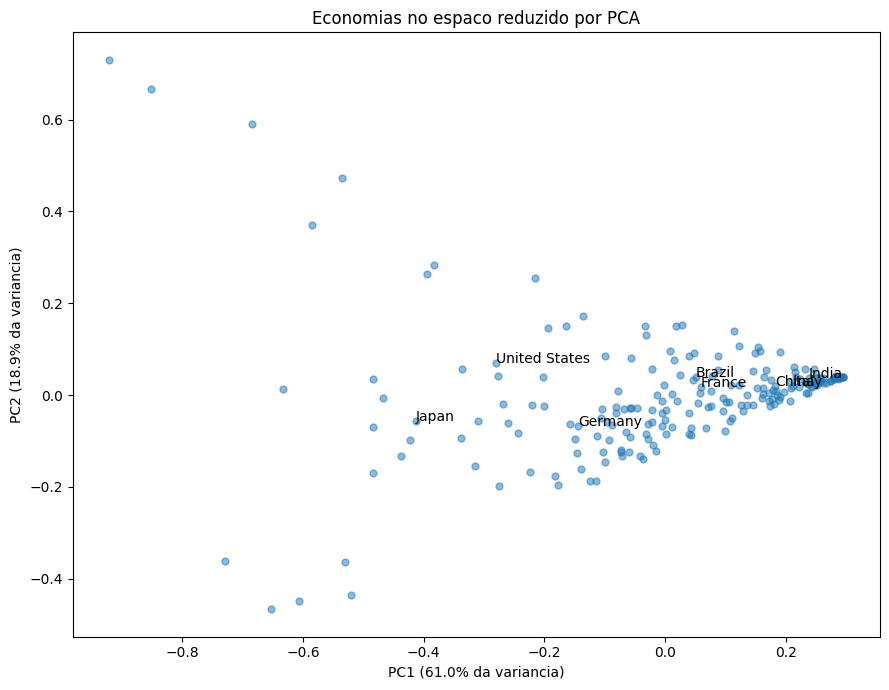

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(componentes[:, 0], componentes[:, 1], alpha=0.5, s=25)

destaques = [
    "China", "United States", "Japan", "Brazil",
    "Germany", "India", "Italy", "France",
]
for pais in destaques:
    if pais in perfil_pct.index:
        idx = perfil_pct.index.get_loc(pais)
        ax.annotate(pais, (componentes[idx, 0], componentes[idx, 1]))

ax.set_xlabel(f"PC1 ({variancia_explicada[0]:.1%} da variancia)")
ax.set_ylabel(f"PC2 ({variancia_explicada[1]:.1%} da variancia)")
ax.set_title("Economias no espaco reduzido por PCA")
plt.tight_layout()
plt.show()

### 8.5 K-Means: quantos grupos fazem sentido?
Duas ferramentas para decidir *k*: o método do cotovelo (inércia) e o coeficiente de silhueta.

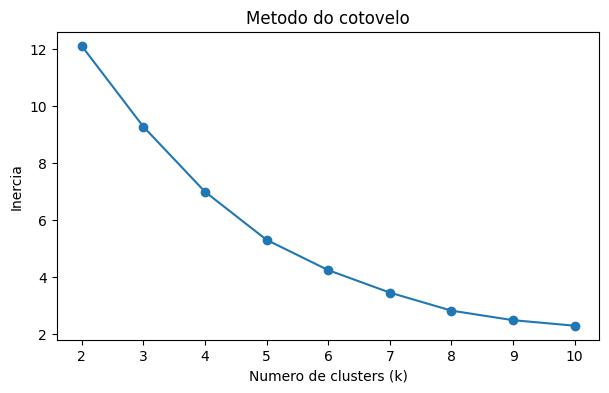

In [7]:
from sklearn.cluster import KMeans

inercias = []
valores_k = range(2, 11)

for k in valores_k:
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_teste.fit(perfil_pct)
    inercias.append(kmeans_teste.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(valores_k), inercias, marker="o")
ax.set_xlabel("Numero de clusters (k)")
ax.set_ylabel("Inercia")
ax.set_title("Metodo do cotovelo")
plt.show()

**coeficiente de silhueta**

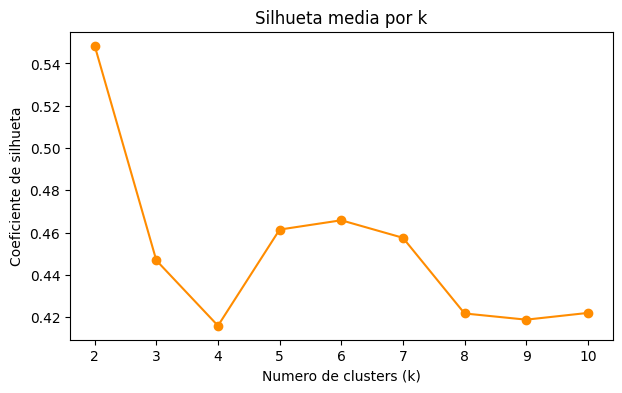

k=2: silhueta = 0.548
k=3: silhueta = 0.447
k=4: silhueta = 0.416
k=5: silhueta = 0.461
k=6: silhueta = 0.466
k=7: silhueta = 0.458
k=8: silhueta = 0.422
k=9: silhueta = 0.419
k=10: silhueta = 0.422


In [8]:
from sklearn.metrics import silhouette_score

silhuetas = []
for k in valores_k:
    kmeans_teste = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_teste = kmeans_teste.fit_predict(perfil_pct)
    silhuetas.append(silhouette_score(perfil_pct, labels_teste))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(valores_k), silhuetas, marker="o", color="darkorange")
ax.set_xlabel("Numero de clusters (k)")
ax.set_ylabel("Coeficiente de silhueta")
ax.set_title("Silhueta media por k")
plt.show()

for k, s in zip(valores_k, silhuetas):
    print(f"k={k}: silhueta = {s:.3f}")

### 8.6 Ajustando o K-Means final
Ajuste `K_ESCOLHIDO` conforme o cotovelo e a silhueta observados acima.

In [9]:
K_ESCOLHIDO = 4  # ajuste conforme as Celulas 13 e 14

kmeans = KMeans(n_clusters=K_ESCOLHIDO, random_state=42, n_init=10)
perfil_pct["cluster"] = kmeans.fit_predict(perfil_pct)

perfil_pct["cluster"].value_counts().sort_index()

,count
cluster,
0,92
1,24
2,6
3,81


**visualização colorida por cluster**

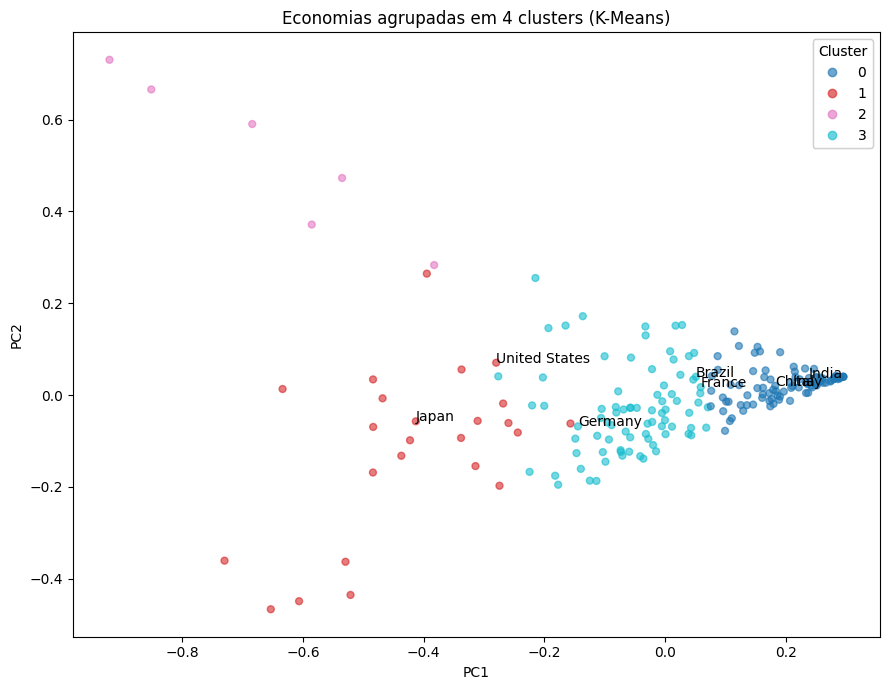

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    componentes[:, 0],
    componentes[:, 1],
    c=perfil_pct["cluster"],
    cmap="tab10",
    alpha=0.6,
    s=25,
)
for pais in destaques:
    if pais in perfil_pct.index:
        idx = perfil_pct.index.get_loc(pais)
        ax.annotate(pais, (componentes[idx, 0], componentes[idx, 1]))

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Economias agrupadas em {K_ESCOLHIDO} clusters (K-Means)")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

### 8.7 Interpretando os clusters
Um cluster sem interpretação de negócio é só um número. Vamos descrever o perfil médio de cada grupo e listar exemplos de países.

In [11]:
colunas_dominio = [c for c in perfil_pct.columns if c != "cluster"]
perfil_medio_cluster = perfil_pct.groupby("cluster")[colunas_dominio].mean()
print("Perfil medio de participacao por cluster:")
print(perfil_medio_cluster.round(3))

print("\nExemplos de economias por cluster:")
for c in sorted(perfil_pct["cluster"].unique()):
    exemplos = perfil_pct[perfil_pct["cluster"] == c].index[:6].tolist()
    print(f"Cluster {c}: {exemplos}")

Perfil medio de participacao por cluster:
fcs_domain  A. Cultural and natural heritage  \
cluster                                        
0                                      0.006   
1                                      0.098   
2                                      0.009   
3                                      0.013   

fcs_domain  B. Performance and celebration / C. Visual arts  \
cluster                                                       
0                                                     0.022   
1                                                     0.091   
2                                                     0.733   
3                                                     0.076   

fcs_domain  C. Visual arts (crafts) / F. Design  D. Books and press  \
cluster                                                               
0                                         0.915               0.039   
1                                         0.351               0.228   
2     

### 8.8 Uma alternativa: agrupamento hierárquico
O K-Means exige escolher *k* de antemão. O agrupamento hierárquico constrói uma árvore (dendrograma) que revela a estrutura em todos os níveis de corte ao mesmo tempo.

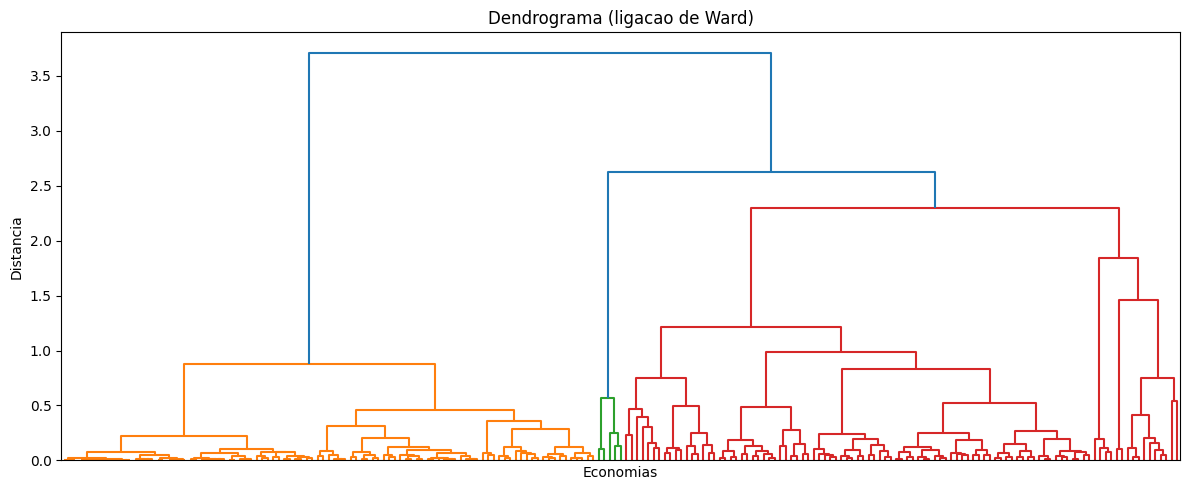

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage

matriz_ligacao = linkage(perfil_pct[colunas_dominio], method="ward")

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(matriz_ligacao, labels=perfil_pct.index.tolist(), ax=ax,
           leaf_rotation=90, leaf_font_size=4, no_labels=True)
ax.set_title("Dendrograma (ligacao de Ward)")
ax.set_xlabel("Economias")
ax.set_ylabel("Distancia")
plt.tight_layout()
plt.show()

**Corte o dendrograma horizontalmente em diferentes alturas e compare com os clusters do K-Means: os grupos coincidem, ou a hierarquia sugere uma estrutura diferente? Essa comparação é o Exercício 5.**

## 🧪 Exercícios Práticos — Aula 8

> **Como usar:** resolva cada exercício em uma célula de código abaixo do enunciado. Depois, leve o resultado para uma IA usando o *prompt sugerido*.

---

### Exercício 1 — Nomeando os clusters
**📝 Tarefa:** Com base no perfil médio da Célula 19, dê um nome de negócio a cada cluster (ex.: "especialistas em audiovisual", "exportadores diversificados"). Justifique cada nome com os números.

**🤖 Pergunte à IA:**
> "Este é o perfil médio de participação por domínio de um cluster de países: [cole a linha]. Que nome de negócio resumiria esse padrão de especialização exportadora?"

---

### Exercício 2 — Onde está o Brasil?
**📝 Tarefa:** Descubra em qual cluster o Brasil caiu e qual é o seu perfil de participação individual (não o médio do cluster). Ele é típico do cluster ou um caso limítrofe?

**🤖 Pergunte à IA:**
> "O Brasil caiu no cluster com perfil médio [cole], mas o perfil individual do Brasil é [cole]. Ele é um membro típico desse grupo ou está na fronteira com outro cluster? Como eu verificaria isso quantitativamente?"

---

### Exercício 3 — PCA com 3 componentes
**📝 Tarefa:** Repita a Seção 8.2 com `n_components=3` em vez de 2. Quanto de variância adicional o terceiro componente explica? Vale a pena, para fins de visualização, usar 3 em vez de 2?

**🤖 Pergunte à IA:**
> "Meus dois primeiros componentes principais explicam [X]% da variância; o terceiro adiciona mais [Y]%. Em que ponto costuma-se considerar que adicionar mais componentes não compensa a perda de interpretabilidade visual?"

---

### Exercício 4 — Sensibilidade ao `k`
**📝 Tarefa:** Rode o K-Means final com `K_ESCOLHIDO = 3` e depois com `K_ESCOLHIDO = 6`. Os clusters de 4 grupos parecem "quebrar" de forma sensata nos outros dois casos, ou os grupos ficam artificiais?

**🤖 Pergunte à IA:**
> "Testei K-Means com k=3, k=4 e k=6 no mesmo dado. As silhuetas foram [X, Y, Z]. Além da silhueta, que critério qualitativo eu deveria usar para decidir o k final em um contexto de segmentação de mercado?"

---

### Exercício 5 — K-Means vs. hierárquico
**📝 Tarefa:** Usando `scipy.cluster.hierarchy.fcluster`, corte o dendrograma da Célula 21 em `K_ESCOLHIDO` grupos e compare essa partição com os rótulos do K-Means (quantos países ficam nos "mesmos" grupos, ainda que numerados diferente?).

**🤖 Pergunte à IA:**
> "Comparei uma partição de K-Means com uma partição de agrupamento hierárquico cortada no mesmo número de grupos, no mesmo dado. [Descreva a semelhança]. Quando essas duas técnicas tendem a divergir mais?"